In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [15]:
file_path = r'/content/glass.xlsx'
glass_df = pd.read_excel(file_path, sheet_name=None)

In [16]:
glass_df

{'Description':    Prepare a model for glass classification using Random Forest
 0                                   Data Description:          
 1                               RI : refractive index          
 2   Na: Sodium (unit measurement: weight percent i...          
 3                                       Mg: Magnesium          
 4                                        AI: Aluminum          
 5                                         Si: Silicon          
 6                                         K:Potassium          
 7                                         Ca: Calcium          
 8                                          Ba: Barium          
 9                                            Fe: Iron          
 10                                                NaN          
 11             Type: Type of glass: (class attribute)          
 12              1 -- building_windows_float_processed          
 13           2 --building_windows_non_float_processed          
 14       

In [17]:
print("Sheet names:", glass_df.keys())

Sheet names: dict_keys(['Description', 'glass'])


In [18]:
glass_df = pd.read_excel(file_path, sheet_name='glass')

In [19]:
glass_df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [20]:
print(glass_df.head())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [22]:
glass_df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [ ]:
# There are no  missing values

In [29]:
glass_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


**Reasoning**:
I will generate histograms for each numerical feature in the `glass_df` DataFrame, excluding the 'Type' column, to visualize their distributions. Each histogram will have a descriptive title.



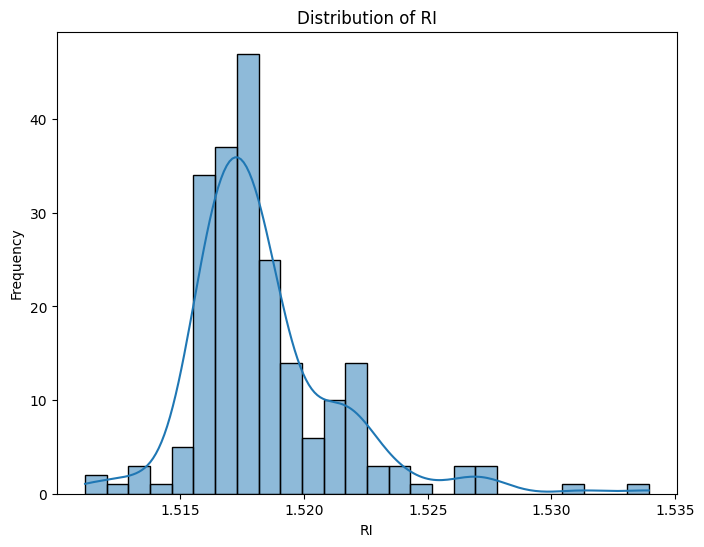

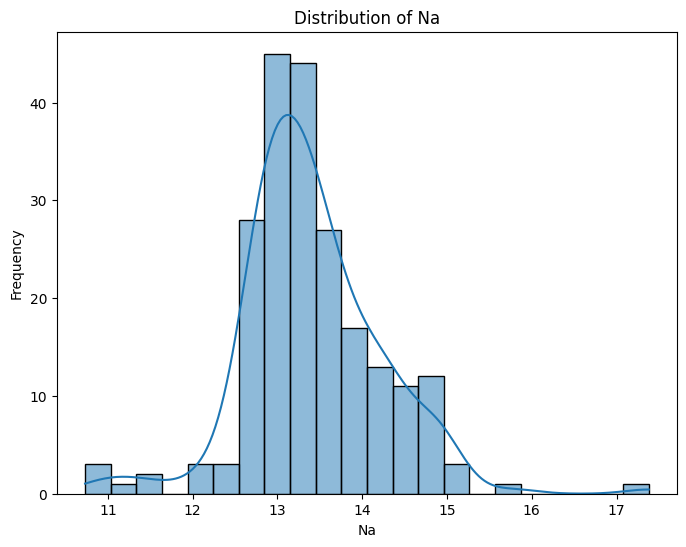

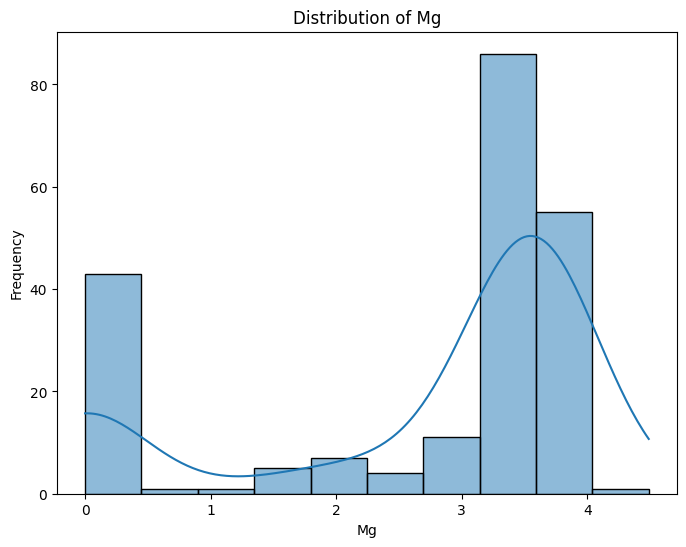

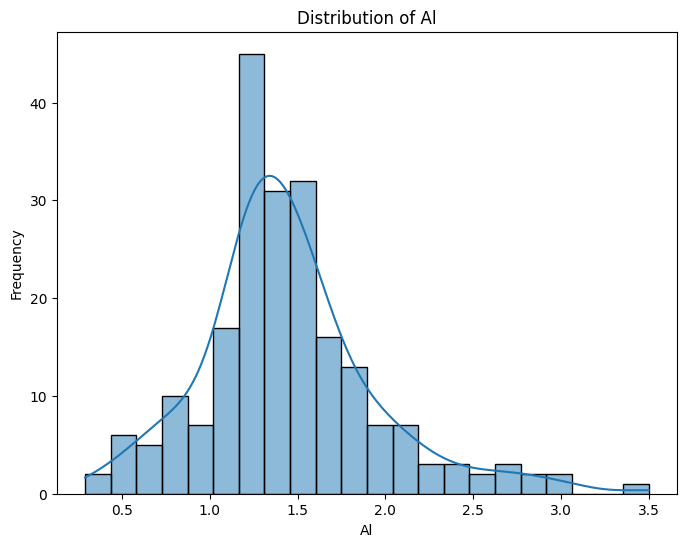

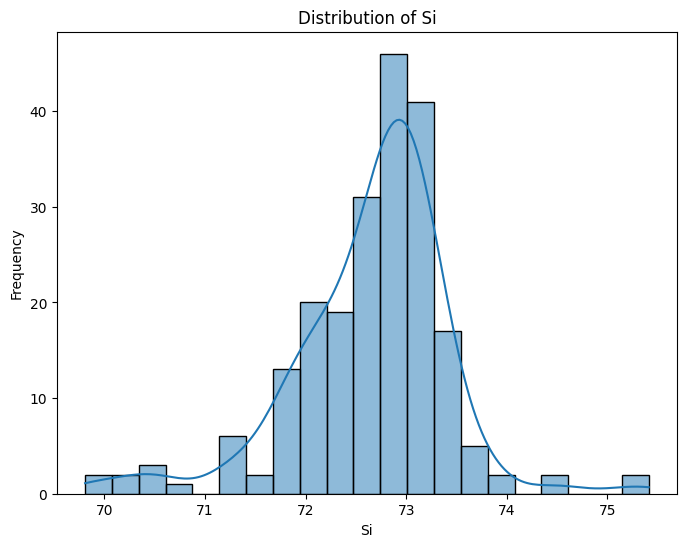

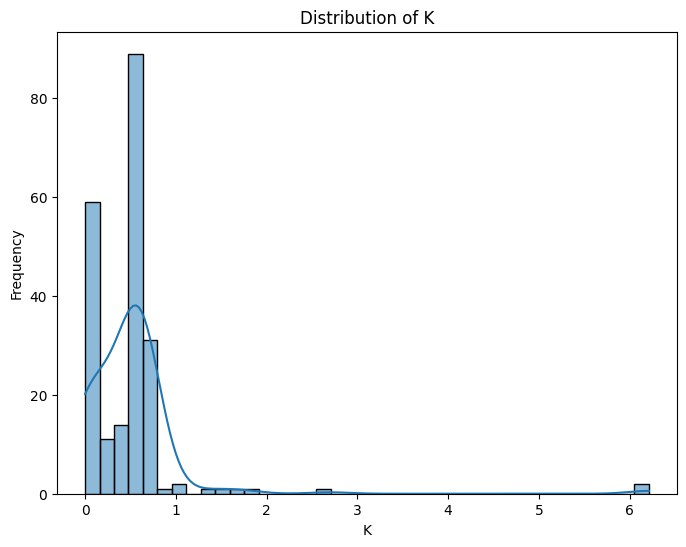

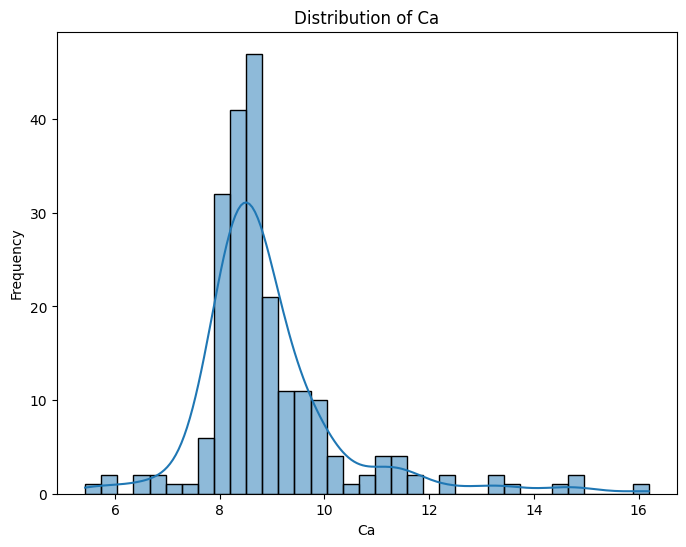

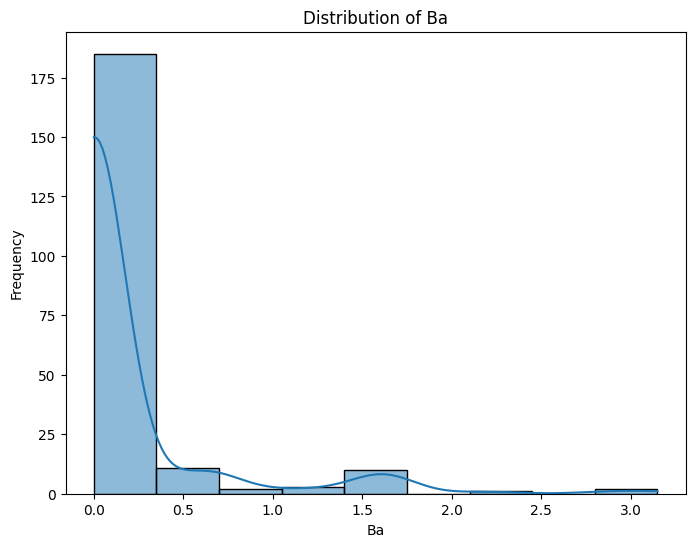

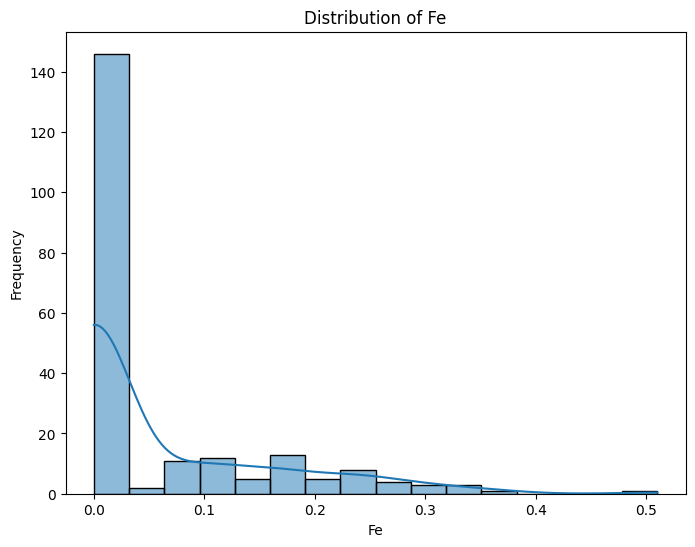

Histograms for all numerical features except 'Type' have been generated.


In [24]:
for column in glass_df.columns:
    if column != 'Type':
        plt.figure(figsize=(8, 6))
        sns.histplot(glass_df[column], kde=True)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()
print("Histograms for all numerical features except 'Type' have been generated.")

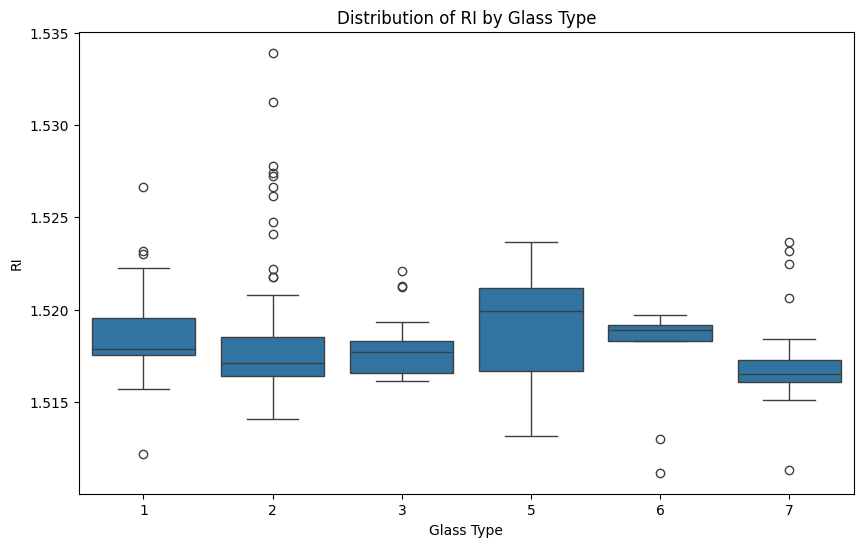

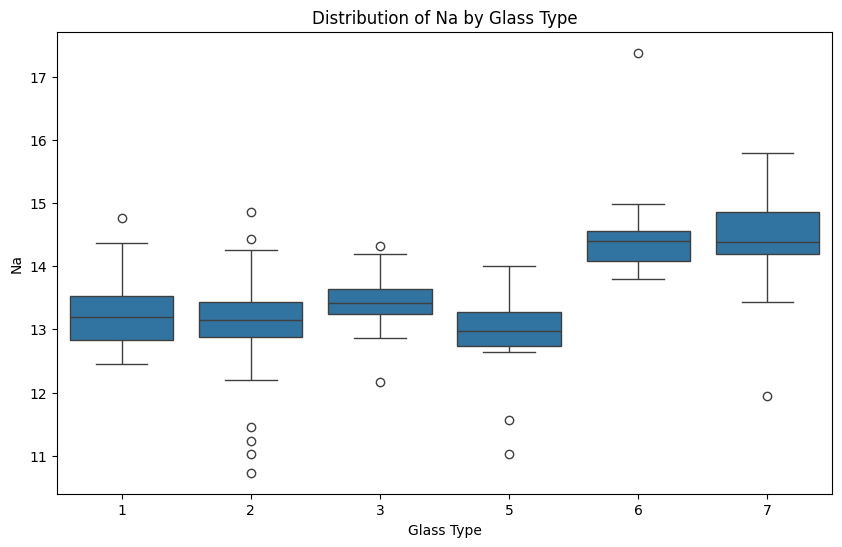

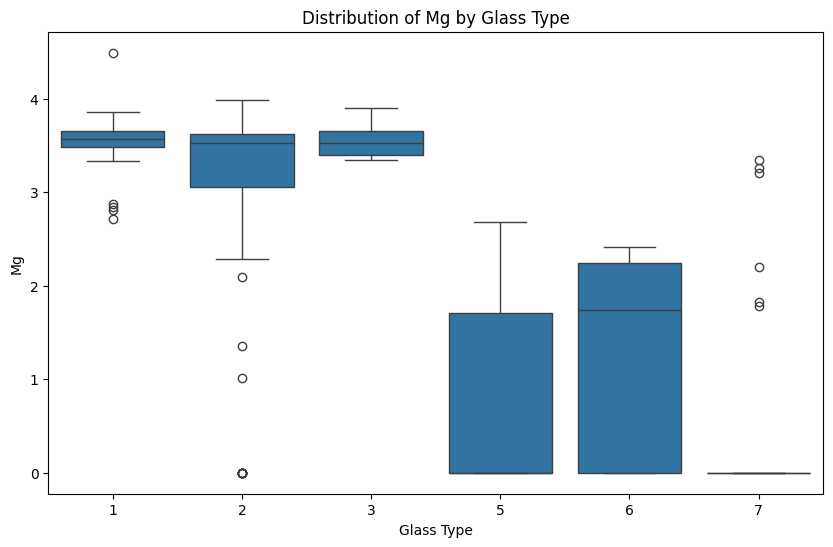

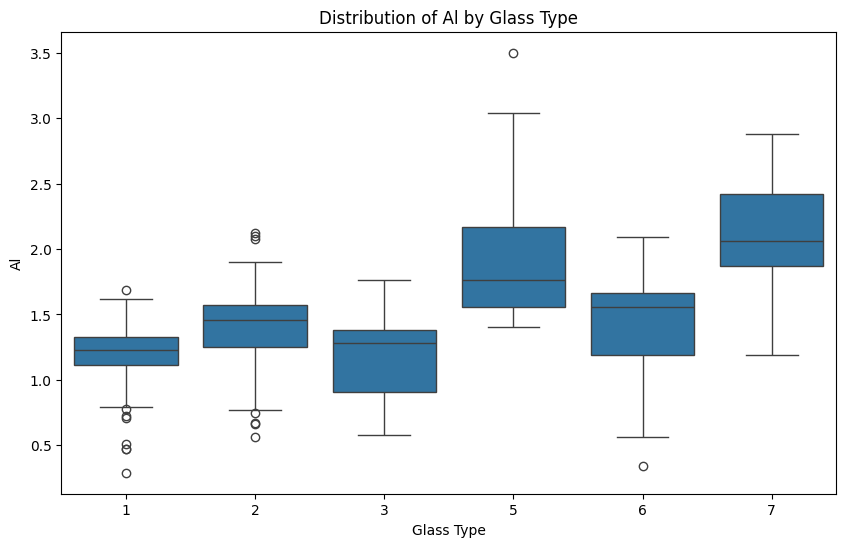

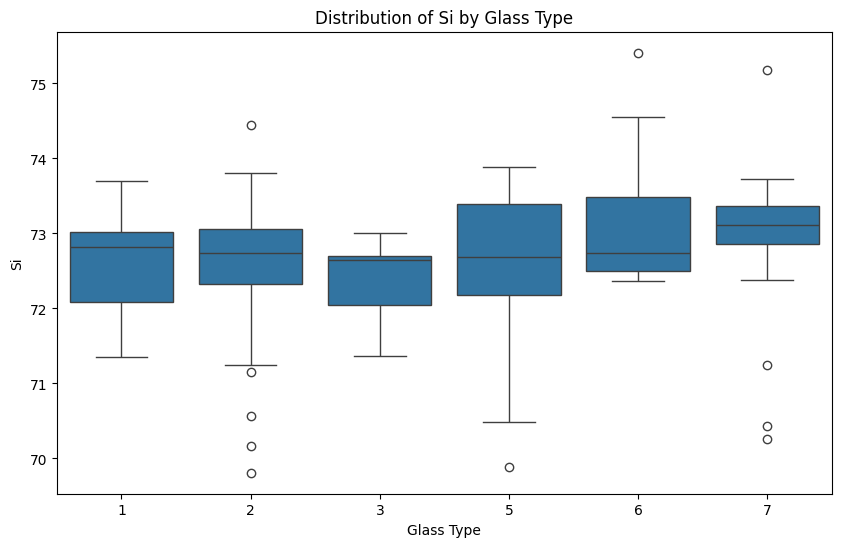

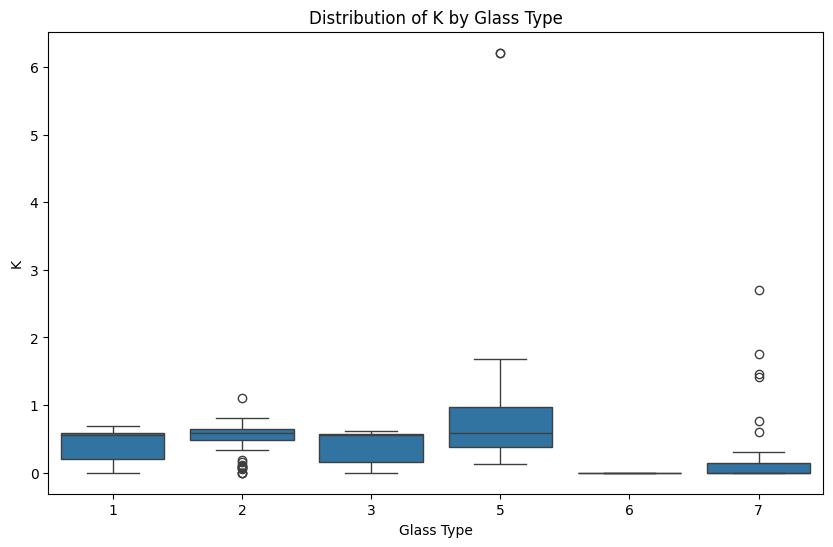

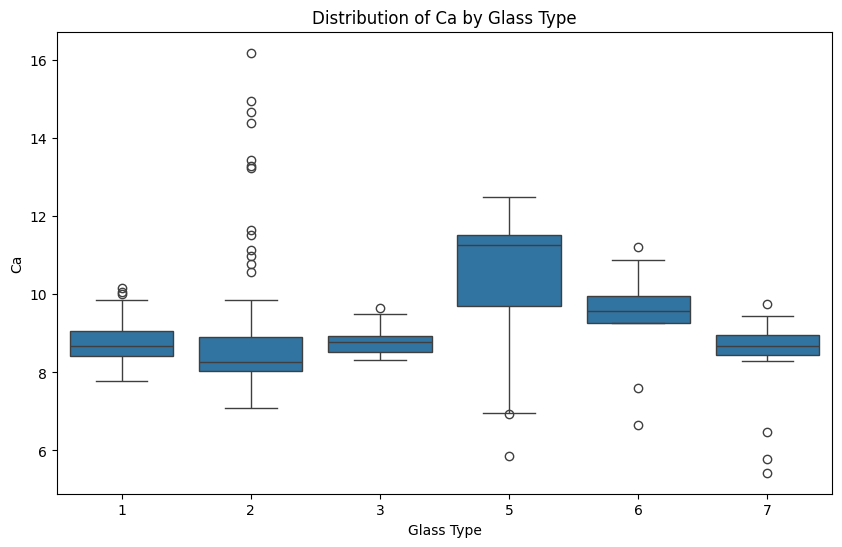

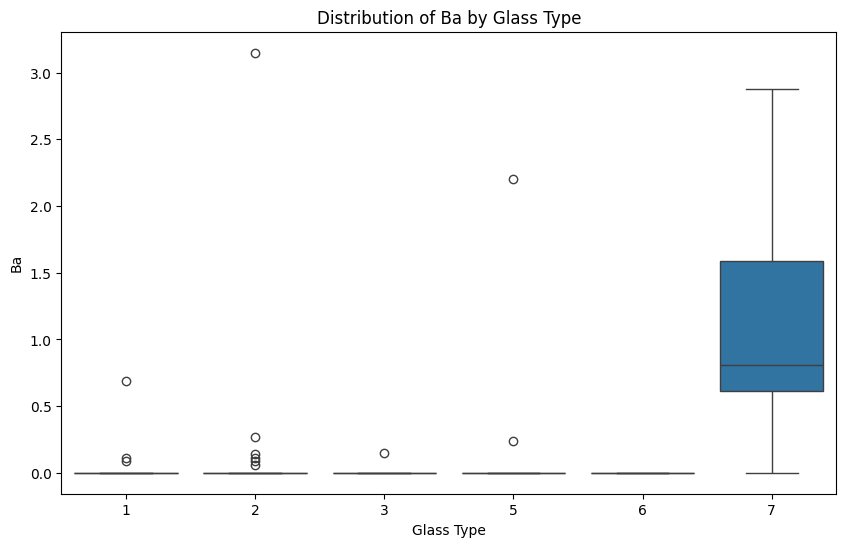

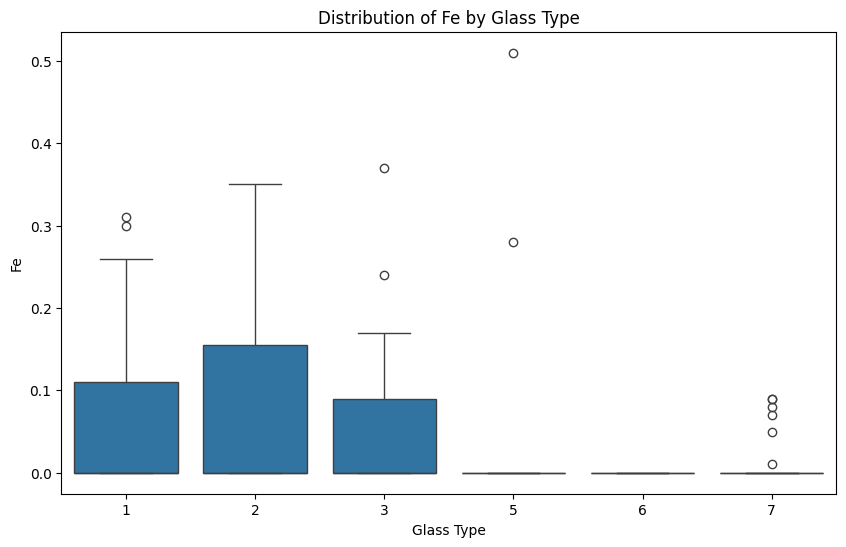

Box plots for all numerical features grouped by 'Type' have been generated.


In [25]:
for column in glass_df.columns:
    if column != 'Type':
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Type', y=column, data=glass_df)
        plt.title(f'Distribution of {column} by Glass Type')
        plt.xlabel('Glass Type')
        plt.ylabel(column)
        plt.show()
print("Box plots for all numerical features grouped by 'Type' have been generated.")

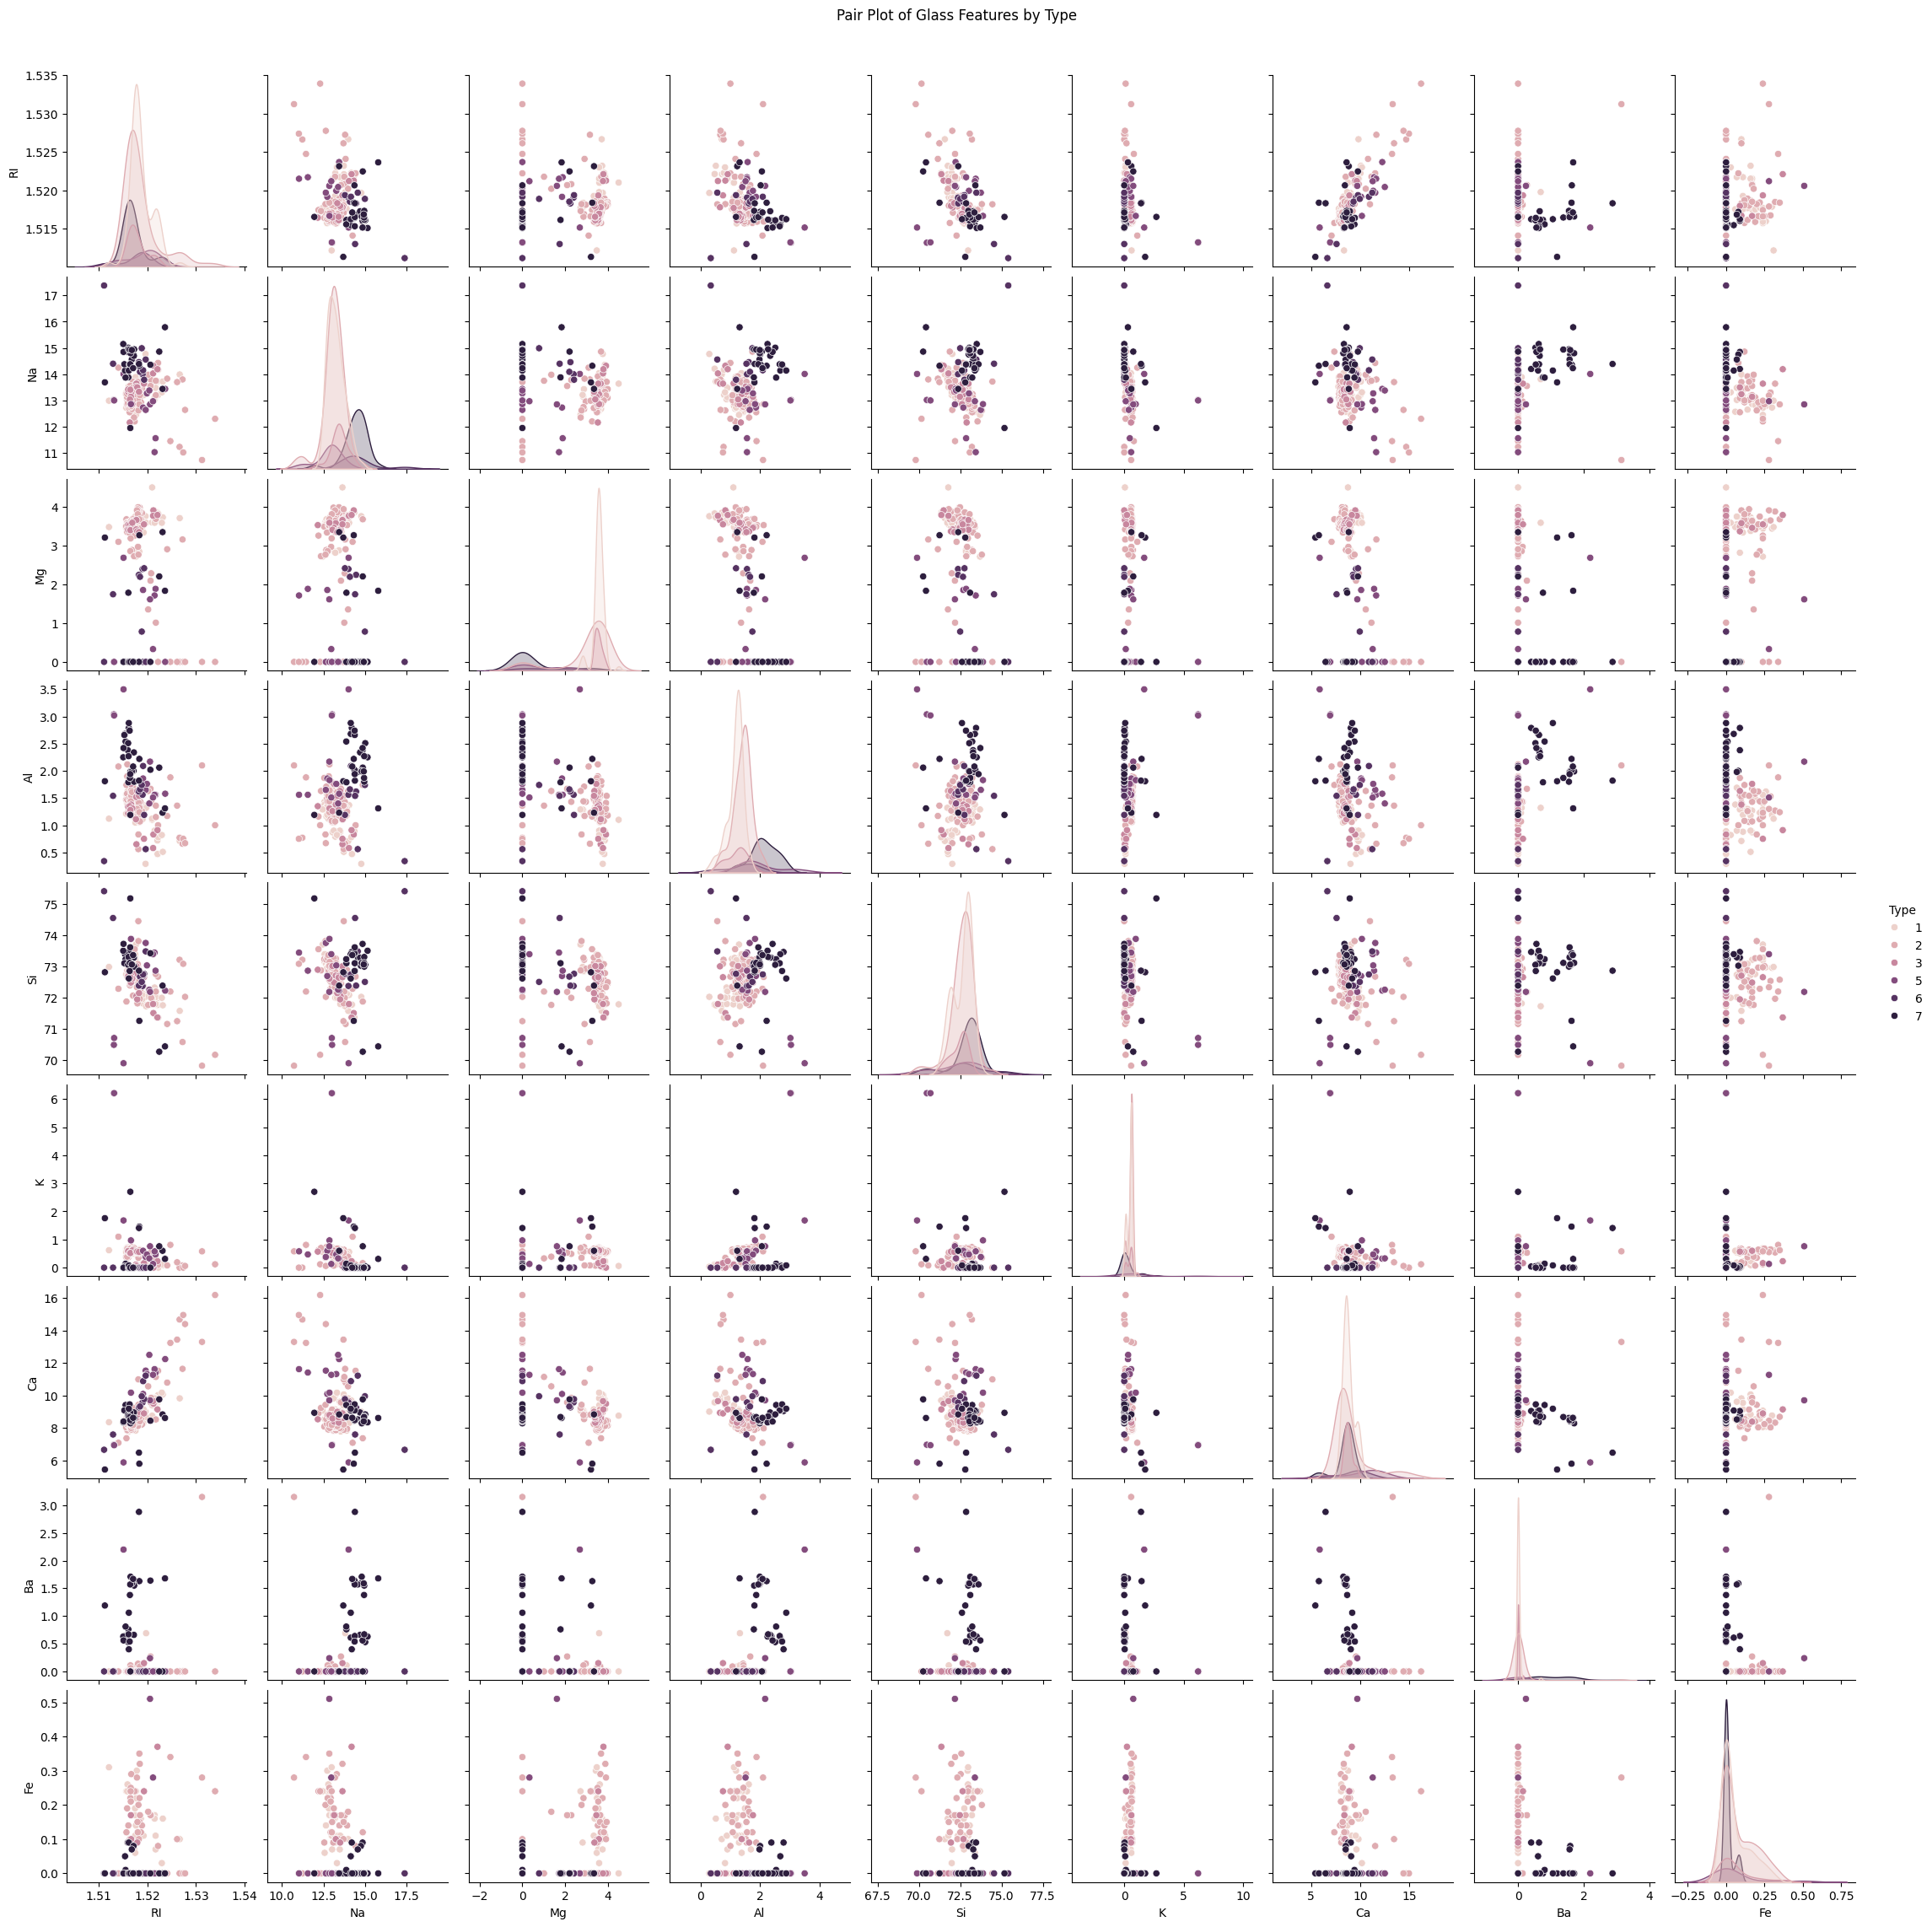

Pair plot showing relationships between features, colored by 'Type', has been generated.


In [26]:
sns.pairplot(glass_df, hue='Type', diag_kind='kde')
plt.suptitle('Pair Plot of Glass Features by Type', y=1.02) # Adjust suptitle position
plt.show()
print("Pair plot showing relationships between features, colored by 'Type', has been generated.")

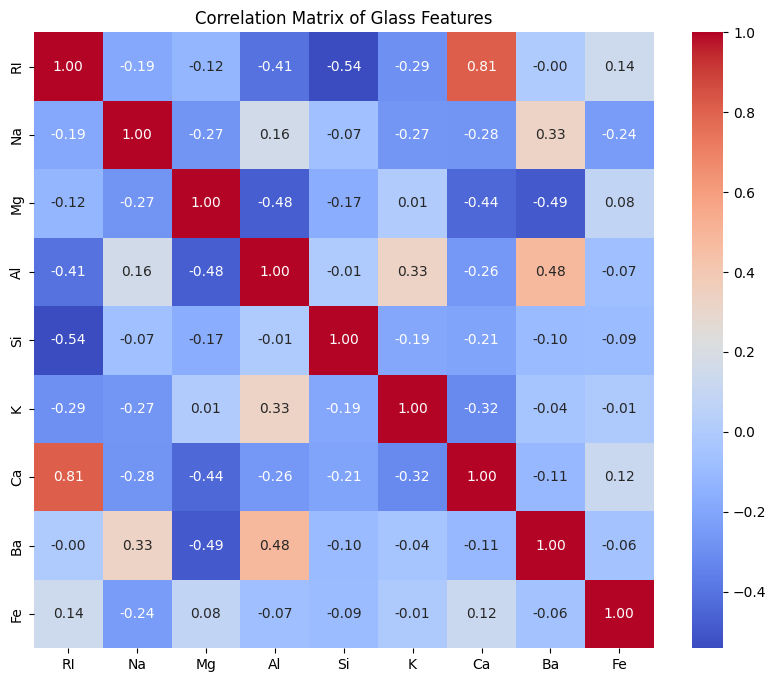

Correlation matrix heatmap of numerical features has been generated.


In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(glass_df.drop('Type', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Glass Features')
plt.show()
print("Correlation matrix heatmap of numerical features has been generated.")

**Reasoning**:
I will create the feature set `X` by dropping the 'Type' column from the `glass_df` DataFrame and the target variable `y` by selecting the 'Type' column, then display the first few rows of both to verify the separation.



In [30]:
X = glass_df.drop('Type', axis=1)
y = glass_df['Type']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0

Target (y) head:
0    1
1    1
2    1
3    1
4    1
Name: Type, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (171, 9)
X_test shape: (43, 9)
y_train shape: (171,)
y_test shape: (43,)


**Reasoning**:
I will instantiate a RandomForestClassifier with a specified random state and then train it using the X_train and y_train datasets as per the instructions.



In [32]:
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)
print("RandomForestClassifier has been instantiated and trained.")

RandomForestClassifier has been instantiated and trained.


**Reasoning**:
Now that the `RandomForestClassifier` has been instantiated and trained, I will use the trained model to make predictions on the test set (`X_test`) to prepare for evaluation.



In [34]:
y_pred = random_forest_model.predict(X_test)
print("Predictions on X_test have been made.")

Predictions on X_test have been made.


**Reasoning**:
To evaluate the performance of the trained RandomForestClassifier, I will calculate and print the accuracy, precision, recall, and F1-score using the true labels (`y_test`) and the predicted labels (`y_pred`).



In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.8372
Precision: 0.8668
Recall: 0.8372
F1-score: 0.8330


## Apply Bagging Method

### Subtask:
Instantiate and train a BaggingClassifier using a DecisionTreeClassifier as the base estimator, then make predictions on the test set.


In [38]:
dt_classifier = DecisionTreeClassifier(random_state=42)
bagging_model = BaggingClassifier(estimator=dt_classifier, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print("BaggingClassifier with DecisionTreeClassifier base estimator has been instantiated, trained, and predictions on X_test have been made.")

BaggingClassifier with DecisionTreeClassifier base estimator has been instantiated, trained, and predictions on X_test have been made.


**Reasoning**:
Now that the `BaggingClassifier` has been trained and predictions (`y_pred_bagging`) have been made on the test set, I will evaluate its performance by calculating and printing the accuracy, precision, recall, and F1-score.



In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging, average='weighted', zero_division=0)
recall_bagging = recall_score(y_test, y_pred_bagging, average='weighted', zero_division=0)
f1_bagging = f1_score(y_test, y_pred_bagging, average='weighted', zero_division=0)

print(f"Bagging Classifier Accuracy: {accuracy_bagging:.4f}")
print(f"Bagging Classifier Precision: {precision_bagging:.4f}")
print(f"Bagging Classifier Recall: {recall_bagging:.4f}")
print(f"Bagging Classifier F1-score: {f1_bagging:.4f}")

Bagging Classifier Accuracy: 0.8372
Bagging Classifier Precision: 0.8419
Bagging Classifier Recall: 0.8372
Bagging Classifier F1-score: 0.8334


## Apply Boosting Method (AdaBoost)

### Subtask:
Instantiate and train an AdaBoostClassifier using a DecisionTreeClassifier as the base estimator, then make predictions on the test set.


**Reasoning**:
I will import `AdaBoostClassifier`, instantiate a `DecisionTreeClassifier` and an `AdaBoostClassifier` with the decision tree as its base estimator, train the `AdaBoostClassifier` on the training data, and then make predictions on the test set as per the instructions.



In [40]:
from sklearn.ensemble import AdaBoostClassifier

dt_ada_classifier = DecisionTreeClassifier(random_state=42)
adaboost_model = AdaBoostClassifier(estimator=dt_ada_classifier, random_state=42)
adaboost_model.fit(X_train, y_train)
y_pred_adaboost = adaboost_model.predict(X_test)

print("AdaBoostClassifier with DecisionTreeClassifier base estimator has been instantiated, trained, and predictions on X_test have been made.")

AdaBoostClassifier with DecisionTreeClassifier base estimator has been instantiated, trained, and predictions on X_test have been made.


**Reasoning**:
Now that the `AdaBoostClassifier` has been trained and predictions (`y_pred_adaboost`) have been made on the test set, I will evaluate its performance by calculating and printing the accuracy, precision, recall, and F1-score.



In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
precision_adaboost = precision_score(y_test, y_pred_adaboost, average='weighted', zero_division=0)
recall_adaboost = recall_score(y_test, y_pred_adaboost, average='weighted', zero_division=0)
f1_adaboost = f1_score(y_test, y_pred_adaboost, average='weighted', zero_division=0)

print(f"AdaBoost Classifier Accuracy: {accuracy_adaboost:.4f}")
print(f"AdaBoost Classifier Precision: {precision_adaboost:.4f}")
print(f"AdaBoost Classifier Recall: {recall_adaboost:.4f}")
print(f"AdaBoost Classifier F1-score: {f1_adaboost:.4f}")

AdaBoost Classifier Accuracy: 0.7674
AdaBoost Classifier Precision: 0.7990
AdaBoost Classifier Recall: 0.7674
AdaBoost Classifier F1-score: 0.7600


In [ ]:
'''
1. Explain Bagging and Boosting methods. How is it different from each other.
Bagging builds multiple models in parallel to reduce variance, while Boosting builds models sequentially to reduce bias.

2. Explain how to handle imbalance in the data.
Imbalanced data is handled by resampling (oversampling or undersampling), adjusting class weights, using synthetic data generation like SMOTE, and evaluating with metrics such as precision, recall, F1-score, or ROC-AUC instead of accuracy.